In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# **1-Data Retrival**

# Loading and Inspection  the Dataset
I loaded the training and testing datasets using pandas.  
Then, I checked their shapes and displayed the first rows to understand the data structure.

In [60]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
#Dataset Inspection:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Display first 5 rows of training data
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Memory Management:

I used a dictionary to assign more efficient data types to each column.  
After reloading the dataset with these types, the memory usage decreased from about 3.43 MB to 0.29 MB.

In [61]:
# Display column data types
train.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [62]:
# Memory usage before optimization
print("the memory before:")
print(train.memory_usage(deep=True).sum() / 1024**2, "MB")

the memory before:
3.434030532836914 MB


In [63]:
# Create an empty dictionary to store optimized data types
dtype_dict = {}

for col in train.columns:
    if train[col].dtype == 'object':
        # Convert text columns to category
        dtype_dict[col] = 'category'
    elif train[col].dtype == 'float64':
        # Reduce floatfrom float64 to float32
        dtype_dict[col] = 'float32'
    elif train[col].dtype == 'int64':
        # Reduce integer size from int64 to int32
        dtype_dict[col] = 'int32'

# Display the dictionary with optimized data types
dtype_dict

{'Id': 'int32',
 'MSSubClass': 'int32',
 'MSZoning': 'category',
 'LotFrontage': 'float32',
 'LotArea': 'int32',
 'Street': 'category',
 'Alley': 'category',
 'LotShape': 'category',
 'LandContour': 'category',
 'Utilities': 'category',
 'LotConfig': 'category',
 'LandSlope': 'category',
 'Neighborhood': 'category',
 'Condition1': 'category',
 'Condition2': 'category',
 'BldgType': 'category',
 'HouseStyle': 'category',
 'OverallQual': 'int32',
 'OverallCond': 'int32',
 'YearBuilt': 'int32',
 'YearRemodAdd': 'int32',
 'RoofStyle': 'category',
 'RoofMatl': 'category',
 'Exterior1st': 'category',
 'Exterior2nd': 'category',
 'MasVnrType': 'category',
 'MasVnrArea': 'float32',
 'ExterQual': 'category',
 'ExterCond': 'category',
 'Foundation': 'category',
 'BsmtQual': 'category',
 'BsmtCond': 'category',
 'BsmtExposure': 'category',
 'BsmtFinType1': 'category',
 'BsmtFinSF1': 'int32',
 'BsmtFinType2': 'category',
 'BsmtFinSF2': 'int32',
 'BsmtUnfSF': 'int32',
 'TotalBsmtSF': 'int32',
 'Hea

In [64]:
# Reload train dataset with optimized data types
train = pd.read_csv("data/train.csv", dtype=dtype_dict)
print("the memory after:")
print(train.memory_usage(deep=True).sum() / 1024**2, "MB")

the memory after:
0.29235076904296875 MB


In [65]:
# Verify new data types
train.dtypes

,0
Id,int32
MSSubClass,int32
MSZoning,category
LotFrontage,float32
LotArea,int32
...,...
MoSold,int32
YrSold,int32
SaleType,category
SaleCondition,category


# **2. Data Cleaning**

# Missing Value Analysis:

I displayed all columns and cheked how many missing values each column has.

Then I handeled the missing values:
- For categorical features, I filled them with "None" to represent the absense of a feature.
- For numerical features, I filled them using the median to reduce the efect of outliers.

I verified that all missing values were handled succesfully, and the total number of missing values became 0 (np.int64(0)).
For some features such as PoolQC, Alley, and Fence, missing values indicate the absence of the feature rather than missing data.

In [66]:
# Identify columns with missing values
missing = train.isnull().sum().sort_values(ascending=False)

# Show columns that have missing values
missing = missing[missing > 0]

missing.head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [67]:
# Select categorical columns (after dtype optimization)
cat_cols = train.select_dtypes(include=['object', 'category']).columns

# Select numerical columns (after dtype optimization)
num_cols = train.select_dtypes(include=['int32', 'float32', 'int64', 'float64']).columns


# Fill missing categorical values
for col in cat_cols:
    if train[col].dtype.name == 'category':
        train[col] = train[col].cat.add_categories(["None"])
    train[col] = train[col].fillna("None")


# Fill missing numerical values
for col in num_cols:
    train[col] = train[col].fillna(train[col].median())

In [68]:
 #display the total number of missing values
train.isnull().sum().sum()

np.int64(0)

# Outlier Removal:

I plotted the distribution of SalePrice to see how the values are spread.  
The plot shows that the data is right-skewed, which means most prices are lower and a few are very high.

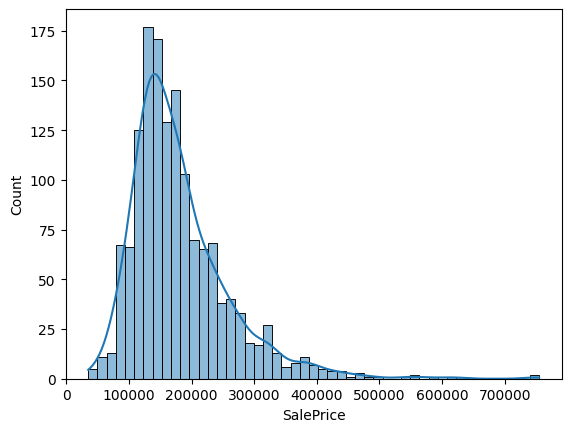

In [69]:
# Plot distribution of SalePrice to check how values are spread
sns.histplot(train["SalePrice"], kde=True)
plt.show()

From the scatter plot, most data points follow a clear positive relationship between GrLivArea and SalePrice.

However, there are a few points on the bottom right with very large living area but unusually low prices.  
These points do not follow the general trend and can negatively affect the model.
so I disided to remove these  as outliers.

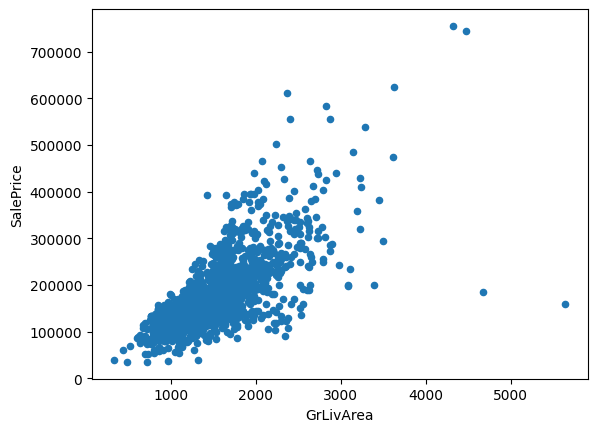

In [70]:
# Plot relationship between living area and sale price
train.plot.scatter(x="GrLivArea", y="SalePrice")
plt.show()

I sorted the data by GrLivArea to check the largest houses and compare their prices.  
This helped me notice that some houses have very large areas but unusually low prices, which indicates the presence of outliers.  

For example, a house with GrLivArea = 5642 has a SalePrice = 160000, which does not match the general pattern.

In [71]:
train.sort_values(by="GrLivArea", ascending=False)[["GrLivArea", "SalePrice"]].head(10)

,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750
1182,4476,745000
691,4316,755000
1169,3627,625000
185,3608,475000
304,3493,295000
1268,3447,381000
635,3395,200000
769,3279,538000


In the lab lecture, the outliers were removed manually.  But I used a condition-based approach instead, because I see that these outliers in a specific region of the plot (large GrLivArea with low SalePrice).  

So I defined a rule to remove all points in that region, which makes the method more general and avoids selecting rows manually.

In [72]:
train = train[~((train["GrLivArea"] > 4500) & (train["SalePrice"] < 300000))]

I plotted the data again after removing the outliers.  
The two points in the bottom-right are gone, and the data looks more clear and consistent now.

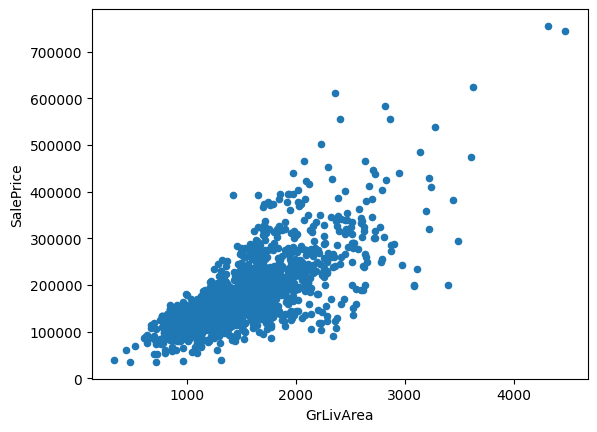

In [73]:
train.plot.scatter(x="GrLivArea", y="SalePrice")
plt.show()

# Data Transformation:

I plotted SalePrice before and after applying log transformation.

Before the transformation, the data was right-skewed (skewness = 1.88), which means most values are low and a few are very high.  
After applying np.log1p, the skewness decreased to 0.12 and the distribution became more balanced.

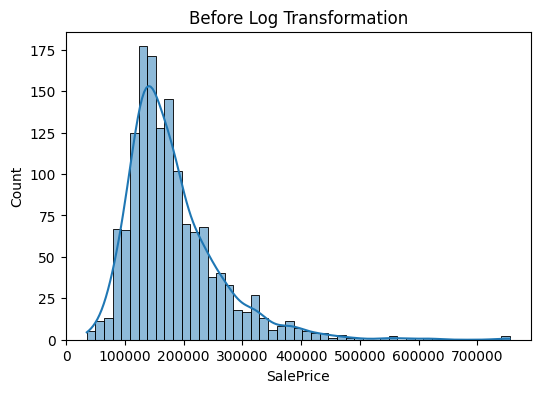

Skewness BEFORE: 1.8812964895244009


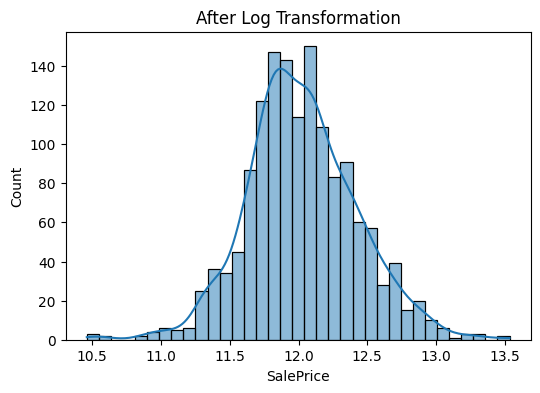

Skewness AFTER: 0.12157976050304879


In [74]:
# plot distribution before log transformation
plt.figure(figsize=(6,4))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Before Log Transformation")
plt.show()

# check skewness before transformation
print("Skewness BEFORE:", train["SalePrice"].skew())

# apply log transformation (copy to avoid warning)
train = train.copy()
train["SalePrice"] = np.log1p(train["SalePrice"])

# plot distribution after log transformation
plt.figure(figsize=(6,4))
sns.histplot(train["SalePrice"], kde=True)
plt.title("After Log Transformation")
plt.show()

# check skewness after transformation
print("Skewness AFTER:", train["SalePrice"].skew())

# **3-Exploratory Data Analysis (EDA)**

# Correlation Analysis:

In [75]:
# compute correlation matrix for numerical features
corr = train.corr(numeric_only=True)

# display first rows of the matrix
corr.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011121,-0.020139,-0.037689,-0.030213,0.012925,-0.013463,-0.022694,-0.053952,-0.015012,...,-0.030262,-0.002115,0.003103,-0.046600,0.001491,0.048476,-0.006195,0.023511,0.000378,-0.017774
MSSubClass,0.011121,1.000000,-0.374402,-0.142033,0.032522,-0.059275,0.027757,0.040503,0.023423,-0.074434,...,-0.012681,-0.006659,-0.012002,-0.043813,-0.026004,0.008090,-0.007675,-0.013581,-0.021386,-0.073969
LotFrontage,-0.020139,-0.374402,1.000000,0.274299,0.219256,-0.050705,0.110368,0.076284,0.150829,0.133126,...,0.069811,0.105055,0.014333,0.066042,0.042121,0.100311,0.000600,0.023932,0.006792,0.351551
LotArea,-0.037689,-0.142033,0.274299,1.000000,0.091392,-0.002723,0.007462,0.007500,0.083715,0.175320,...,0.168621,0.061861,-0.016505,0.021362,0.045288,0.036491,0.039072,0.005744,-0.013699,0.260544
OverallQual,-0.030213,0.032522,0.219256,0.091392,1.000000,-0.090442,0.571368,0.549827,0.398785,0.222467,...,0.236753,0.297186,-0.113176,0.030991,0.066298,0.044758,-0.031238,0.072531,-0.026575,0.821405


I used a heatmap to better understand the relationships between features.
From the heatmap, we can clearly see that some features have stronger correlation with SalePrice, shown by darker colors.  
On the far right side (and bottom row), the darkest values appear for features like:
- OverallQual  
- GrLivArea  
- GarageCars  
- GarageArea  
- TotalBsmtSF  
These darker colors indicate a strong positive correlation, meaning that as these features increase, the SalePrice also tends to increase.
This helps identify the most important features for predicting house prices.

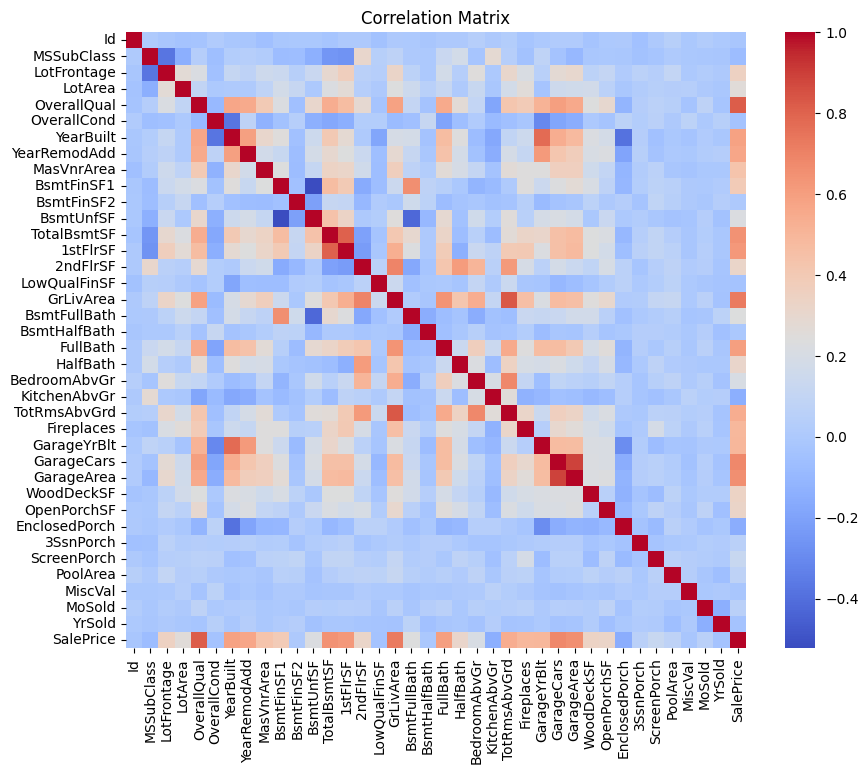

In [76]:
# plot heatmap to visualize correlation between features
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [77]:
# Get correlation with SalePrice
corr_target = corr["SalePrice"].sort_values(ascending=False)

corr_target

,SalePrice
SalePrice,1.000000
OverallQual,0.821405
GrLivArea,0.725211
GarageCars,0.681033
GarageArea,0.656129
TotalBsmtSF,0.647563
1stFlrSF,0.620500
FullBath,0.595899
YearBuilt,0.587043
YearRemodAdd,0.565992


From the correlation results  the OverallQual has the strongest correlation with SalePrice, followed by GrLivArea, GarageCars, GarageArea, and TotalBsmtSF.

In [78]:
# Top 5 features (excluding SalePrice itself)
top_features = corr_target[1:6]

top_features

,SalePrice
OverallQual,0.821405
GrLivArea,0.725211
GarageCars,0.681033
GarageArea,0.656129
TotalBsmtSF,0.647563


# Visual Exploration:

I plotted GrLivArea against SalePrice and used OverallQual as color.
The plot shows a clear positive relationship, where larger houses tend to have higher prices.  
We can also see that houses with higher quality (darker colors) are generally more expensive.
This confirms that both size and quality have a strong impact on SalePrice.

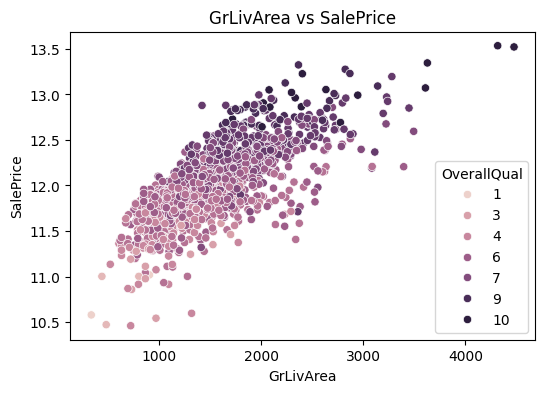

In [79]:
# Scatter plot: GrLivArea vs SalePrice colored by OverallQual
plt.figure(figsize=(6,4))

sns.scatterplot(
    x=train["GrLivArea"],
    y=train["SalePrice"],
    hue=train["OverallQual"]
)

plt.title("GrLivArea vs SalePrice")
plt.show()

# Geographical Insights:

I calculated the average SalePrice for each Neighborhood and visualized it using a bar plot.
The differences between neighborhoods are not very large in the plot because the target variable was log-transformed, but there is still variation in average prices across locations.
This shows that location still has an effect on house prices.

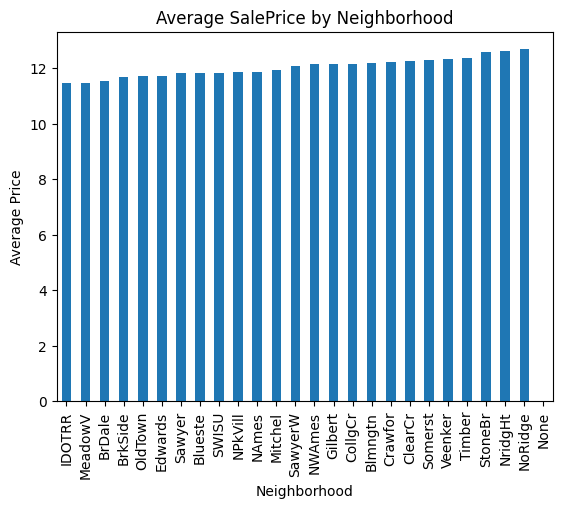

In [80]:
# Average price per neighborhood
avg_price = train.groupby("Neighborhood", observed=False)["SalePrice"].mean()
# Plot
avg_price.sort_values().plot(kind="bar")

plt.title("Average SalePrice by Neighborhood")
plt.ylabel("Average Price")
plt.show()

# **4. Feature Engineering**

## Note
i used this for practice and result checking.  
It is commented out because encoding is already handled inside the preprocessing pipeline.  

if i didnt get it commented out, it will cause a KeyError because the categorical columns are already transformed inside the pipeline, so they no longer exist in their original form

# Feature Transformation:

In [56]:
#Create TotalSF feature by summing basement, first floor, and second floor areas
#train["TotalSF"] = train["TotalBsmtSF"] + train["1stFlrSF"] + train["2ndFlrSF"]

# Check the result
#train[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF
0,856,856,854,2566
1,1262,1262,0,2524
2,920,920,866,2706
3,756,961,756,2473
4,1145,1145,1053,3343


# Encoding Categorical Variables:  

## Label Encoding



I examined the values of ExterQual and KitchenQual to confirm that they follow a natural ordinal relationshi TA < Gd < Ex. Therefore, label encoding was applied to preserve this ranking. Only key ordinal features were encoded for simplicity.

In [26]:
# Display the first few values of ordinal features
train[["ExterQual", "KitchenQual"]].head()

,ExterQual,KitchenQual
0,Gd,Gd
1,TA,TA
2,Gd,Gd
3,TA,Gd
4,Gd,Gd


I converted `ExterQual` and `KitchenQual` into numbers using label encoding because they have a natural order.

In [27]:
# Label Encoding for ordinal features (with ranking)
#qual_map = {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5}

#train["ExterQual"] = train["ExterQual"].map(qual_map)
#train["KitchenQual"] = train["KitchenQual"].map(qual_map)

# Check result
#train[["ExterQual", "KitchenQual"]].head()

,ExterQual,KitchenQual
0,4.0,4.0
1,3.0,3.0
2,4.0,4.0
3,3.0,4.0
4,4.0,4.0


# One-Hot Encoding

In [28]:
# One-Hot Encoding for nominal features (with 0/1)
#train = pd.get_dummies(
#   train,
#  columns=["Neighborhood", "BldgType"],
# drop_first=True,
#dtype=int
#)

In [29]:
# Check new Neighborhood columns
#train.filter(like="Neighborhood_").head()

,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,...,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Neighborhood_None
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# Check new BldgType columns
#train.filter(like="BldgType_").head(10)

,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,BldgType_None
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
5,0,0,0,0,0
6,0,0,0,0,0
7,0,0,0,0,0
8,0,0,0,0,0
9,1,0,0,0,0


# **`# Pipeline Construction:`**

i created this function to combine the main cleaning and transformation steps in one place.

The function first makes a copy of the dataset so the original data is not changed directly.  
Then it creates the `TotalSF` feature because the total house area can affect the house price.

After that, it handles missing values:
- categorical columns are filled with `"None"`
- numerical columns are filled with the median

I also used label encoding for `ExterQual` and `KitchenQual` because these columns have a clear order from poor to excellent.  
For nominal columns like `Neighborhood` and `BldgType`, I used one-hot encoding because they do not have a natural order.

The reason for using this function is to apply the same preprocessing steps to both the training and testing datasets, so the data stays consistent and ready for modeling.
i used reusable function instead of a scikit-learn Pipeline for simplicity and clarity, while still ensuring consistent preprocessing.

In [82]:
def preprocess_data(df):
    df = df.copy()

    # Feature Engineering
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

    # Missing values
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    num_cols = df.select_dtypes(include=["int32", "float32", "int64", "float64"]).columns

    for col in cat_cols:
        df[col] = df[col].fillna("None")

    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Ordinal Encoding
    qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

    for col in ["ExterQual", "KitchenQual"]:
        df[col] = df[col].map(qual_map).fillna(0)

    # One-Hot Encoding
    df = pd.get_dummies(
        df,
        columns=["Neighborhood", "BldgType"],
        drop_first=True,
        dtype=int
    )

    return df

i applied the preprocessing function to both the training and testing datasets to ensure that the same steps are used for both.

After that, I separated the target variable (SalePrice) from the training data:
- X_train contains the features
- y_train contains the target variable

For the test data, I aligned its columns with the training data using reindex.  
This is important because after one-hot encoding, the number of columns can be different between train and test.

By doing this, both datasets have the same structure, which is required for building a regression model.

In [83]:
# apply preprocessing function to train and test data
train_processed = preprocess_data(train)
test_processed = preprocess_data(test)

# separate features and target variable
X_train = train_processed.drop("SalePrice", axis=1)
y_train = train_processed["SalePrice"]

# align test data columns with training data after encoding
X_test = test_processed.reindex(columns=X_train.columns, fill_value=0)

# check shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

# preview processed features
X_train.head()

X_train shape: (1458, 109)
y_train shape: (1458,)
X_test shape: (1459, 109)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Neighborhood_None,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,BldgType_None
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,0,0,0,0,0,0,0,0,0,0
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,0,0,1,0,0,0,0,0,0
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,0,0,0,0,0,0,0,0,0,0
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,0,0,0,0,0,0,0,0,0,0
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,0,0,0,0,0,0,0,0,0,0


In [84]:
# check if TotalSF was successfully added to the features
print("In X_test:", "TotalSF" in X_test.columns)
print("In X_train:", "TotalSF" in X_train.columns)

In X_test: True
In X_train: True
